In [1]:
from pathlib import Path
from datetime import datetime
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from scipy.stats import spearmanr, kendalltau
from lightgbm import LGBMRegressor

PROCESSED_DIR = Path("data/processed")
TABLES_DIR = Path("outputs/tables")
FIGURES_DIR = Path("outputs/figures")
MODELS_DIR = Path("outputs/models")
RANDOM_STATE = 42

for folder in [TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

cards = pd.read_csv(PROCESSED_DIR / "pokemon_priced_features.csv", low_memory=False)

with open(PROCESSED_DIR / "feature_groups.json", encoding="utf-8") as file:
    groups = json.load(file)

features = (
    groups["intrinsic_features"]
    + groups["extrinsic_features"]
    + groups["extrinsic_interaction_features"]
)

X = cards[features]
y = cards["Log_Value"]

indices = np.arange(len(cards))
train_idx, test_idx = train_test_split(indices, test_size=.2, random_state=RANDOM_STATE)
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [2]:
def make_pipeline(X):
    categorical = X.select_dtypes(exclude=np.number).columns.tolist()
    numeric = X.select_dtypes(include=np.number).columns.tolist()

    preprocessor = ColumnTransformer([
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
        ]), categorical),
        ("num", SimpleImputer(strategy="median"), numeric)
    ])

    model = LGBMRegressor(
        n_estimators=800, learning_rate=.03, num_leaves=31,
        subsample=.85, colsample_bytree=.85,
        reg_lambda=2, reg_alpha=.1,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )

    return Pipeline([("preprocessor", preprocessor), ("model", model)])

def evaluate(y_train, train_pred, y_test, test_pred):
    metrics = {}
    for split, actual, predicted in [
        ("train", y_train, train_pred), ("test", y_test, test_pred)
    ]:
        price = np.expm1(actual)
        price_pred = np.maximum(np.expm1(predicted), 0)
        metrics[split + "_log_MAE"] = mean_absolute_error(actual, predicted)
        metrics[split + "_log_RMSE"] = mean_squared_error(actual, predicted) ** .5
        metrics[split + "_log_R2"] = r2_score(actual, predicted)
        metrics[split + "_price_MAE"] = mean_absolute_error(price, price_pred)
        metrics[split + "_price_RMSE"] = mean_squared_error(price, price_pred) ** .5
    metrics["RMSE_gap"] = metrics["test_log_RMSE"] - metrics["train_log_RMSE"]
    metrics["test_price_R2"] = r2_score(np.expm1(y_test), np.maximum(np.expm1(test_pred), 0))
    metrics["spearman_rank"] = spearmanr(y_test, test_pred).correlation
    metrics["kendall_rank"] = kendalltau(y_test, test_pred).correlation
    return metrics

In [3]:
holdout_model = make_pipeline(X_train)
holdout_model.fit(X_train, y_train)

train_pred = holdout_model.predict(X_train)
test_pred = holdout_model.predict(X_test)

metrics = evaluate(y_train, train_pred, y_test, test_pred)
metrics_table = pd.DataFrame([{
    "model": "LightGBM",
    "feature_set": "Intrinsic + extrinsic",
    "feature_count": len(features),
    **metrics
}])

display(metrics_table.T)
metrics_table.to_csv(TABLES_DIR / "final_lightgbm_metrics.csv", index=False, encoding="utf-8-sig")

C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['card_number_printed_total' 'card_position_ratio_intrinsic']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['card_number_printed_total' 'card_position_ratio_intrinsic']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed 

,0
model,LightGBM
feature_set,Intrinsic + extrinsic
feature_count,55
train_log_MAE,0.221738
train_log_RMSE,0.365954
train_log_R2,0.895452
train_price_MAE,4.242233
train_price_RMSE,52.47785
test_log_MAE,0.246741
test_log_RMSE,0.412865


In [4]:
def prediction_table(row_indices, truth, prediction, split):
    result = cards.loc[row_indices, [
        "Card Name", "Set Name", "Collection", "Card Number",
        "Rarity", "Card Type", "Card Category", "HP"
    ]].reset_index(drop=True)

    result["split"] = split
    result["actual_log_value"] = np.asarray(truth)
    result["predicted_log_value"] = prediction
    result["residual_log"] = result["actual_log_value"] - result["predicted_log_value"]
    result["absolute_log_error"] = result["residual_log"].abs()
    result["actual_value"] = np.expm1(result["actual_log_value"])
    result["predicted_value"] = np.maximum(np.expm1(result["predicted_log_value"]), 0)
    result["residual_value"] = result["actual_value"] - result["predicted_value"]
    result["absolute_value_error"] = result["residual_value"].abs()
    return result

train_predictions = prediction_table(train_idx, y_train, train_pred, "train")
test_predictions = prediction_table(test_idx, y_test, test_pred, "test")

pd.concat([train_predictions, test_predictions]).to_csv(
    TABLES_DIR / "final_lightgbm_train_test_predictions.csv", index=False, encoding="utf-8-sig"
)
test_predictions.to_csv(TABLES_DIR / "final_lightgbm_test_predictions.csv", index=False, encoding="utf-8-sig")

In [5]:
price_bins = [0, 1, 5, 10, 25, 50, 100, 250, 500, np.inf]
price_labels = ["≤£1", "£1-£5", "£5-£10", "£10-£25", "£25-£50", "£50-£100", "£100-£250", "£250-£500", ">£500"]

test_predictions["price_band"] = pd.cut(
    test_predictions["actual_value"],
    price_bins,
    labels=price_labels,
    include_lowest=True
)

error_by_band = test_predictions.groupby("price_band", observed=False).agg(
    card_count=("actual_value", "size"),
    median_actual_value=("actual_value", "median"),
    mean_absolute_log_error=("absolute_log_error", "mean"),
    mean_absolute_price_error=("absolute_value_error", "mean")
).reset_index()

display(error_by_band)
error_by_band.to_csv(TABLES_DIR / "final_lightgbm_error_by_price_band.csv", index=False, encoding="utf-8-sig")

,price_band,card_count,median_actual_value,mean_absolute_log_error,mean_absolute_price_error
0,≤£1,4286,0.39,0.121985,0.221105
1,£1-£5,1515,2.07,0.342123,1.336712
2,£5-£10,505,6.79,0.436147,3.456115
3,£10-£25,402,14.79,0.531973,7.607701
4,£25-£50,192,33.59,0.600130,16.809822
5,£50-£100,126,67.99,0.590346,31.038542
6,£100-£250,72,143.99,0.732513,71.149058
7,£250-£500,28,359.99,0.779351,150.583648
8,>£500,21,799.99,1.144297,486.046085


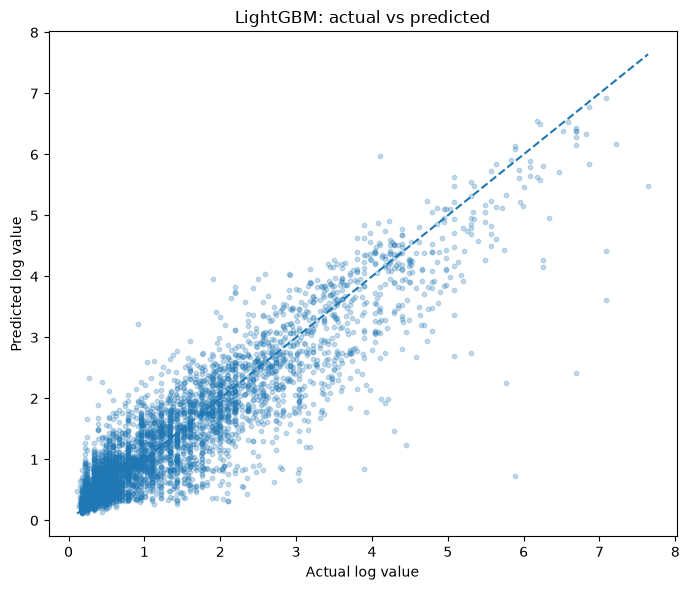

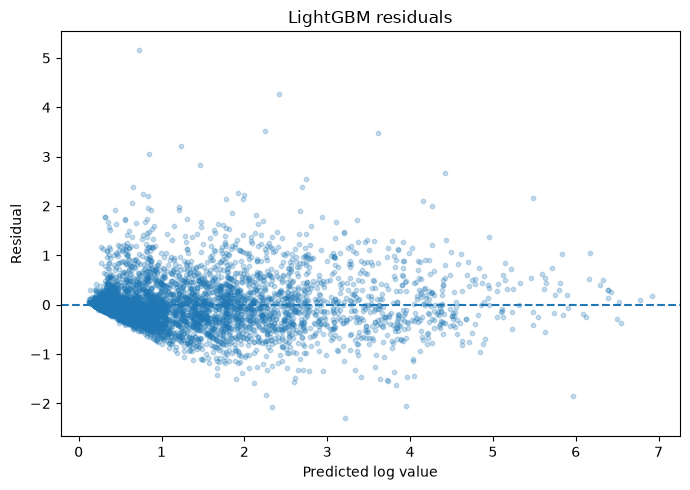

In [6]:
plt.figure(figsize=(7, 6))
plt.scatter(test_predictions["actual_log_value"], test_predictions["predicted_log_value"], alpha=.25, s=10)
limits = [
    test_predictions[["actual_log_value", "predicted_log_value"]].min().min(),
    test_predictions[["actual_log_value", "predicted_log_value"]].max().max()
]
plt.plot(limits, limits, "--")
plt.xlabel("Actual log value")
plt.ylabel("Predicted log value")
plt.title("LightGBM: actual vs predicted")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_lightgbm_actual_vs_predicted.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(test_predictions["predicted_log_value"], test_predictions["residual_log"], alpha=.25, s=10)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log value")
plt.ylabel("Residual")
plt.title("LightGBM residuals")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_lightgbm_residuals.png", dpi=200)
plt.show()

In [7]:
full_model = make_pipeline(X)
full_model.fit(X, y)

joblib.dump(holdout_model, MODELS_DIR / "final_lightgbm_holdout_model.joblib")
joblib.dump(full_model, MODELS_DIR / "final_lightgbm_full_model.joblib")

pd.DataFrame({"feature": features}).to_csv(
    TABLES_DIR / "final_model_features.csv",
    index=False,
    encoding="utf-8-sig"
)

metadata = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "model": "LightGBM Regressor",
    "feature_set": "Intrinsic + extrinsic",
    "features": features,
    "target": "Log_Value = log(1 + Value)",
    "test_size": .2,
    "random_state": RANDOM_STATE,
    "metrics": metrics
}

with open(MODELS_DIR / "final_lightgbm_metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2, default=float)

print("Models saved.")

C:\Users\rayan\PycharmProjects\Dissertation\.venv\Lib\site-packages\sklearn\impute\_base.py:647: UserWarning: Skipping features without any observed values: ['card_number_printed_total' 'card_position_ratio_intrinsic']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Models saved.
